<a href="https://colab.research.google.com/github/Uggina-Manisha/coffee-leaf-disease-prediction/blob/main/coffee_leaf_disease_prediction_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: coffee-leaf-diseases/test/images/1100.jpg  
  inflating: coffee-leaf-diseases/test/images/1101.jpg  
  inflating: coffee-leaf-diseases/test/images/1102.jpg  
  inflating: coffee-leaf-diseases/test/images/1103.jpg  
  inflating: coffee-leaf-diseases/test/images/1104.jpg  
  inflating: coffee-leaf-diseases/test/images/1105.jpg  
  inflating: coffee-leaf-diseases/test/images/1106.jpg  
  inflating: coffee-leaf-diseases/test/images/1107.jpg  
  inflating: coffee-leaf-diseases/test/images/1108.jpg  
  inflating: coffee-leaf-diseases/test/images/1109.jpg  
  inflating: coffee-leaf-diseases/test/images/1110.jpg  
  inflating: coffee-leaf-diseases/test/images/1111.jpg  
  inflating: coffee-leaf-diseases/test/images/1112.jpg  
  inflating: coffee-leaf-diseases/test/images/1113.jpg  
  inflating: coffee-leaf-diseases/test/images/1114.jpg  
  inflating: coffee-leaf-diseases/test/images/1115.jpg  
  inflating: coffee-leaf-diseases/test/images/1116.jpg  
  inflati

In [ ]:
!pip install tensorflow pandas opencv-python matplotlib scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
import os
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:

train_csv = pd.read_csv("/content/train_classes.csv")
test_csv = pd.read_csv("/content/test_classes.csv")

In [ ]:
train_csv = pd.read_csv("/content/train_classes.csv")

train_csv.head()

,id,miner,rust,phoma
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0


In [ ]:
test_csv = pd.read_csv("/content/test_classes.csv")

test_csv.head()

,id,miner,rust,phoma
0,64,1,0,0
1,65,1,0,0
2,66,1,0,0
3,67,1,0,0
4,68,1,0,0


In [ ]:
def get_label(row):

    if row["miner"] == 1:
        return 1
    elif row["rust"] == 1:
        return 2
    elif row["phoma"] == 1:
        return 3
    else:
        return 0   # healthy

train_csv["label"] = train_csv.apply(get_label, axis=1)
test_csv["label"]  = test_csv.apply(get_label, axis=1)

train_csv.head()

,id,miner,rust,phoma,label
0,0,0,0,0,0
1,1,0,0,0,0
2,2,0,0,0,0
3,3,0,0,0,0
4,4,0,0,0,0


In [ ]:
test_csv.head()

,id,miner,rust,phoma,label
0,64,1,0,0,1
1,65,1,0,0,1
2,66,1,0,0,1
3,67,1,0,0,1
4,68,1,0,0,1


In [ ]:
image_path = "/content/coffee-leaf-diseases/train/images"

images = []
labels = []

for index,row in train_csv.iterrows():

    img_name = str(row["id"]) + ".jpg"
    path = os.path.join(image_path,img_name)

    img = cv2.imread(path)
    img = cv2.resize(img,(224,224))
    img = img/255.0

    images.append(img)
    labels.append(row["label"])

images = np.array(images)
labels = np.array(labels)

print(images.shape)
print(labels.shape)

(1264, 224, 224, 3)
(1264,)


In [ ]:
test_path = "/content/coffee-leaf-diseases/test/images"

test_images = []
test_labels = []

for _, row in test_csv.iterrows():
    img_path = os.path.join(test_path, str(row["id"]) + ".jpg")

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    img = img / 255.0

    test_images.append(img)
    test_labels.append(row["label"])

test_images = np.array(test_images)
test_labels = np.array(test_labels)
print(test_images.shape)
print(test_labels.shape)

(400, 224, 224, 3)
(400,)


In [ ]:
from tensorflow.keras.utils import to_categorical
train_labels = to_categorical(labels,num_classes=4)
print(train_labels.shape)
print(test_labels.shape)


(1264, 4)
(400,)


In [ ]:
X_train,X_val,y_train,y_val = train_test_split(
    images,
    train_labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

cnn_model = Sequential()

cnn_model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D())

cnn_model.add(Conv2D(64,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D())

cnn_model.add(Conv2D(128,(3,3),activation='relu'))
cnn_model.add(MaxPooling2D())

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.080128205128205), 1: np.float64(0.9610266159695817), 2: np.float64(1.2035714285714285), 3: np.float64(0.8314144736842105)}


In [ ]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.2829 - loss: 1.5268 - val_accuracy: 0.3636 - val_loss: 1.3377
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.3709 - loss: 1.3228 - val_accuracy: 0.4704 - val_loss: 1.3064
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 112s 4s/step - accuracy: 0.4876 - loss: 1.2028 - val_accuracy: 0.5099 - val_loss: 1.0167
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.5598 - loss: 1.0272 - val_accuracy: 0.5810 - val_loss: 0.9818
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.5737 - loss: 1.0359 - val_accuracy: 0.6285 - val_loss: 0.9633
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.6162 - loss: 0.8843 - val_accuracy: 0.6522 - val_loss: 0.8460
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.6637 - loss: 0.8030 - val_accuracy: 0.6364 - val_loss: 0.8759
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.6884 - loss: 0.7489 - val_accuracy: 0.6008 - v

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
y_pred = cnn_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_val, axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 791ms/step


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred_classes)

print("CNN Accuracy:", accuracy)

CNN Accuracy: 0.7351778656126482


In [ ]:
class_names = ['Healthy','Miner','Rust','Phoma']

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

     Healthy       0.58      0.66      0.62        50
       Miner       0.74      0.65      0.69        69
        Rust       0.67      0.58      0.62        50
       Phoma       0.86      0.94      0.90        84

    accuracy                           0.74       253
   macro avg       0.71      0.71      0.71       253
weighted avg       0.73      0.74      0.73       253



In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  7  3  7]
 [13 45  9  2]
 [ 8  9 29  4]
 [ 3  0  2 79]]


In [ ]:
test_labels.shape

(400,)

In [ ]:
print(test_labels.shape)
print(type(test_labels[0]))
print(test_labels[0])

(400,)
<class 'numpy.int64'>
1


In [ ]:
from sklearn.metrics import accuracy_score

y_pred = cnn_model.predict(test_images)

y_pred_classes = np.argmax(y_pred, axis=1)

accuracy = accuracy_score(test_labels, y_pred_classes)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 786ms/step
Test Accuracy: 0.685


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# predict
y_pred = cnn_model.predict(test_images)

# convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# accuracy
accuracy = accuracy_score(test_labels, y_pred_classes)
print("Test Accuracy:", accuracy)

# report
classes = ['Healthy','Miner','Rust','Phoma']
print(classification_report(test_labels, y_pred_classes, target_names=classes))

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 799ms/step
Test Accuracy: 0.685
              precision    recall  f1-score   support

     Healthy       0.73      0.88      0.80       116
       Miner       0.66      0.57      0.61       128
        Rust       0.27      0.20      0.23        60
       Phoma       0.82      0.91      0.86        96

    accuracy                           0.69       400
   macro avg       0.62      0.64      0.63       400
weighted avg       0.66      0.69      0.67       400



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def cnn_predict_image(image_path):

    # read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img_resized = cv2.resize(img,(224,224))
    img_resized = img_resized/255.0

    img_input = np.reshape(img_resized,(1,224,224,3))

    # prediction
    prediction = cnn_model.predict(img_input)

    classes = ['Healthy','Miner','Rust','Phoma']

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction)

    # show image
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

    print("Predicted Disease:", predicted_class)
    print("Confidence:", confidence)

In [ ]:
from google.colab import files
files.upload()

Saving input2.jpg to input2.jpg


{'input2.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x04\x00\x08\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\x

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


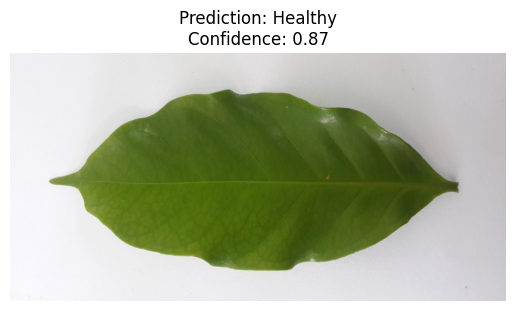

Predicted Disease: Healthy
Confidence: 0.86839795


In [ ]:
cnn_predict_image("/content/input2.jpg")

In [ ]:
from google.colab import files
files.upload()

Saving input4.jpg to input4.jpg


{'input4.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x04\x00\x08\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\x

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


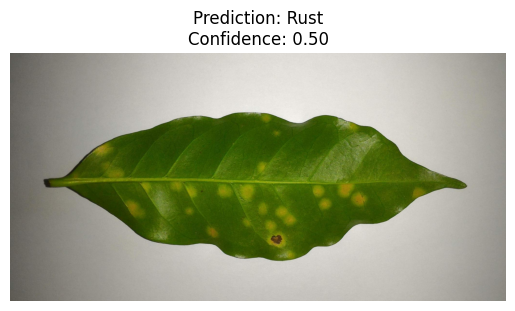

Predicted Disease: Rust
Confidence: 0.4963234


In [ ]:
cnn_predict_image("/content/input4.jpg")

In [ ]:
from google.colab import files
files.upload()

Saving input1.jpg to input1.jpg


{'input1.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x04\x00\x08\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\x

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


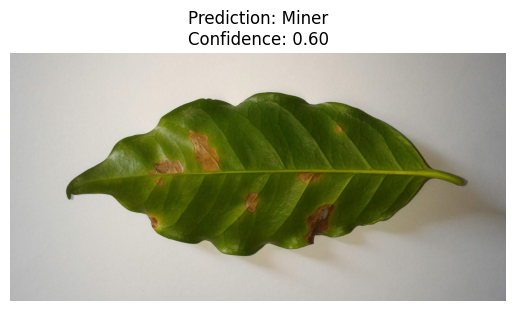

Predicted Disease: Miner
Confidence: 0.60030764


In [ ]:
cnn_predict_image("/content/input1.jpg")

In [ ]:
from google.colab import files
files.upload()

Saving input7.jpg to input7.jpg


{'input7.jpg': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x04\x00\x08\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\x

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


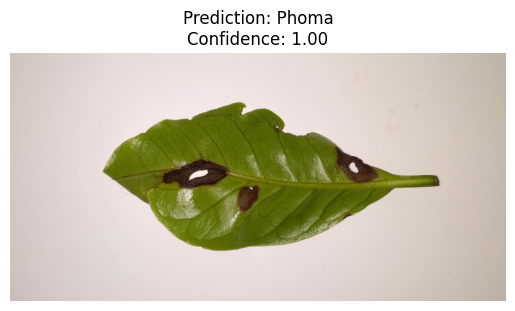

Predicted Disease: Phoma
Confidence: 0.99999654


In [ ]:
cnn_predict_image("/content/input7.jpg")

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
y_pred_prob = cnn_model.predict(test_images)

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


In [ ]:
y_test_bin = label_binarize(test_labels, classes=[0,1,2,3])

In [ ]:
n_classes = 4

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

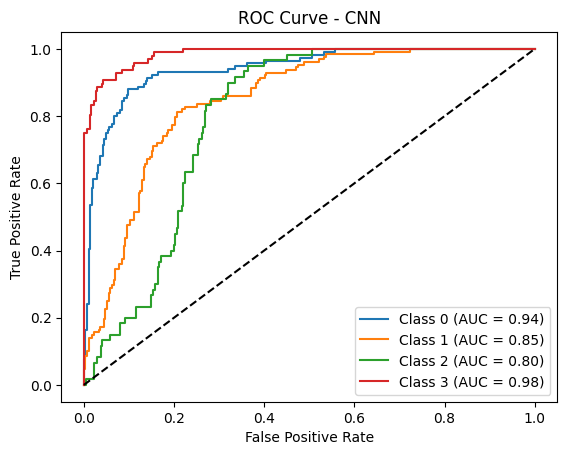

In [ ]:
plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')  # random line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


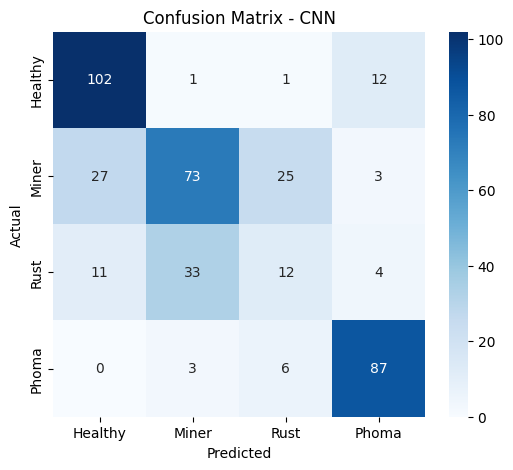

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# predictions
y_pred = cnn_model.predict(test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

# confusion matrix
cm = confusion_matrix(test_labels, y_pred_classes)

# class names
classes = ['Healthy','Miner','Rust','Phoma']

# plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN")
plt.show()

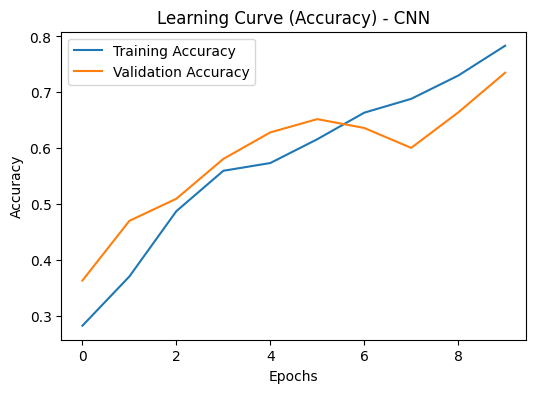

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Accuracy) - CNN')
plt.legend()
plt.show()

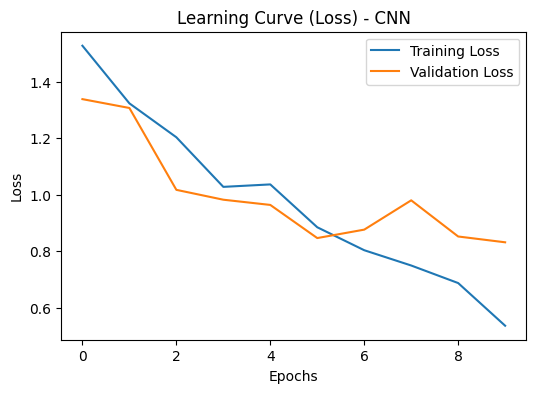

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve (Loss) - CNN')
plt.legend()
plt.show()